# Package

In [1]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "data" / "secom.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import datetime as dt
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
from imblearn.over_sampling import SMOTE
from scipy import stats as sps
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.stats.diagnostic import linear_reset, linear_rainbow, het_breuschpagan
from xgboost import XGBClassifier


---
---

# Load data

In [2]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, 132)])

PCA 保留 131 個主成分


---
---

# Fitted model

In [3]:
def _sample_offsets_block(q, k, n_block, center_first=True, rng=None):
    """
    產生 (n_block, q) 的整數位移 offsets ∈ [-k, k]
    center_first=True：第一筆固定為全 0
    """
    if rng is None:
        rng = np.random.default_rng(0)

    offsets = rng.integers(-k, k + 1, size=(n_block, q), dtype=np.int16).astype(np.float32)
    if center_first and n_block > 0:
        offsets[0, :] = 0.0
    return offsets


def _ols_from_sufficient_stats(Sxx, Sxy, Syy, sum_y, n, q):
    """
    由 sufficient statistics（X'X, X'y, y'y, sum(y)）計算 OLS 係數與統計量
    用累積量求 OLS 係數與統計量
    輸出包含 beta / se / t / p / r2 / aic / bic / df_resi
    """
    p_params = q + 1
    df_resid = n - p_params
    out = {}

    try:
        beta = np.linalg.solve(Sxx, Sxy)
    except np.linalg.LinAlgError:
        beta = np.full(p_params, np.nan, dtype=np.float64)

    if np.all(np.isfinite(beta)):
        SSE = float(Syy - 2.0 * beta @ Sxy + beta @ (Sxx @ beta))
    else:
        SSE = np.nan

    ybar = float(sum_y / n) if n > 0 else np.nan
    TSS = float(Syy - n * (ybar**2)) if n > 0 else np.nan
    sigma2 = float(SSE / df_resid) if (df_resid > 0 and np.isfinite(SSE)) else np.nan

    try:
        Sxx_inv = np.linalg.inv(Sxx)
    except np.linalg.LinAlgError:
        Sxx_inv = np.full_like(Sxx, np.nan, dtype=np.float64)

    if np.isfinite(sigma2) and np.all(np.isfinite(Sxx_inv)):
        cov = sigma2 * Sxx_inv
        se = np.sqrt(np.diag(cov))
        tval = beta / se
        pval = 2.0 * sps.t.sf(np.abs(tval), df=df_resid) if df_resid>0 else np.full_like(tval, np.nan)
    else:
        se = np.full(p_params, np.nan, dtype=np.float64)
        tval = np.full(p_params, np.nan, dtype=np.float64)
        pval = np.full(p_params, np.nan, dtype=np.float64)

    r2 = (1.0 - SSE / TSS) if (np.isfinite(SSE) and np.isfinite(TSS) and TSS > 0) else np.nan

    kparam = p_params
    if n > 0 and np.isfinite(SSE) and SSE > 0:
        ll_term = n * np.log(SSE / n)
        aic = float(ll_term + 2.0 * kparam)
        bic = float(ll_term + np.log(n) * kparam)
    else:
        aic = np.nan
        bic = np.nan

    out["beta"] = beta
    out["SSE"] = SSE
    out["r2"] = float(r2) if np.isfinite(r2) else np.nan
    out["se"] = se
    out["t"] = tval
    out["p"] = pval
    out["aic"] = aic
    out["bic"] = bic
    out["df_resid"] = int(df_resid)
    return out


def local_surrogate_block_sample_ols(
    x0,
    blackbox_model,
    block_cols,
    delta,
    k,
    scaler=None,
    n_block=800_000,
    rng_seed=42,
    store_yhat=False,
    store_yblackbox=False,
):
    """
    在 x0 附近抽樣 n_block 個格點，丟進黑箱得到 y_hat
    一次只用 block_cols 的 q 維特徵做 OLS，輸出係數與 p-value
    """
    x0 = np.asarray(x0, np.float32).reshape(1, -1)

    if scaler is not None:
        x0_scaled = scaler.transform(x0).astype(np.float32, copy=False)
    else:
        x0_scaled = x0.copy()

    p_model = x0_scaled.shape[1]
    block_cols = np.asarray(block_cols, dtype=np.int64)
    q = int(block_cols.size)
    if q < 1:
        raise ValueError("block_cols 至少 1 維")
    if k < 0:
        raise ValueError("k must be >= 0")
    if store_yhat or store_yblackbox:
        raise ValueError("store_yhat/store_yblackbox 在大 n 下不可用（請關掉）。")

    rng = np.random.default_rng(rng_seed)

    offsets_q = _sample_offsets_block(q, k, n_block, center_first=True, rng=rng)
    X_block = (np.float32(delta) * offsets_q).astype(np.float32, copy=False)

    Zs = np.empty((n_block, p_model), dtype=np.float32)
    Zs[:] = x0_scaled
    Zs[:, block_cols] += X_block

    if scaler is not None:
        Z = scaler.inverse_transform(Zs).astype(np.float32, copy=False)
    else:
        Z = Zs

    if hasattr(blackbox_model, "predict_proba"):
        y = blackbox_model.predict_proba(Z)[:, 1]
    else:
        y = blackbox_model.predict(Z)

    y = np.asarray(y, dtype=np.float32).reshape(-1)
    if y.size != n_block:
        raise ValueError("blackbox 輸出長度與 n_block 不一致")

    Sxx = np.zeros((q + 1, q + 1), dtype=np.float64)
    Sxy = np.zeros((q + 1,), dtype=np.float64)

    Sxx[0, 0] = float(n_block)
    sx = X_block.sum(axis=0, dtype=np.float64)
    Sxx[0, 1:] = sx
    Sxx[1:, 0] = sx
    Sxx[1:, 1:] = (X_block.T @ X_block).astype(np.float64, copy=False)

    sy = float(y.sum(dtype=np.float64))
    Sxy[0] = sy
    Sxy[1:] = (X_block.T @ y).astype(np.float64, copy=False)

    Syy = float(y @ y)
    st = _ols_from_sufficient_stats(Sxx, Sxy, Syy, sy, int(n_block), q)

    info = {
        "n": int(n_block),
        "q": int(q),
        "k": int(k),
        "delta": float(delta),
        "block_cols": block_cols.tolist(),
        "coef_block": st["beta"][1:].copy(),
        "intercept": float(st["beta"][0]),
        "se_block": st["se"][1:].copy(),
        "t_block": st["t"][1:].copy(),
        "p_block": st["p"][1:].copy(),
        "intercept_p": float(st["p"][0]) if np.isfinite(st["p"][0]) else np.nan,
        "r2": float(st["r2"]),
        "aic": float(st["aic"]),
        "bic": float(st["bic"]),
        "df_resid": int(st["df_resid"]),
        "rng_seed": int(rng_seed),
    }
    return info


def pick_x0_indices(p, target, topk, min_p=None):
    """
    依 |p - target| 選出最接近 target 的 topk 索引（可加 min_p 過濾）。
    """
    p = np.asarray(p).reshape(-1)
    idx = np.arange(len(p))
    if min_p is not None:
        idx = idx[p[idx] >= min_p]
    if idx.size == 0:
        return idx
    order = np.argsort(np.abs(p[idx] - target))
    return idx[order[:min(topk, idx.size)]]


def run_Nround_fullp_screening(
    x0,
    blackbox_model,
    feature_names,
    thresholds,
    k=3,
    delta=0.1,
    scaler=None,
    n_block=800_000,
    base_seed=42,
):
    """
    對單一 (x0, blackbox) 做多輪抽樣 OLS：
    每輪抽 n_block 個格點、用 active_cols 做 OLS，依門檻縮小 active_cols。
    回傳每輪的統計表 df_all 與最終保留欄位 final_cols。
    """
    p = len(feature_names)
    active_cols = np.arange(p, dtype=np.int64)
    all_round_dfs = []

    for r, thr in enumerate(thresholds, start=1):
        if active_cols.size == 0:
            break

        seed = int(base_seed + r * 100000)

        info = local_surrogate_block_sample_ols(
            x0=x0,
            blackbox_model=blackbox_model,
            block_cols=active_cols,
            delta=delta,
            k=k,
            scaler=scaler,
            n_block=n_block,
            rng_seed=seed,
            store_yhat=False,
            store_yblackbox=False,
        )

        rows = []
        for t, col in enumerate(active_cols):
            rows.append({
                "feature": feature_names[int(col)],
                "feature_idx": int(col),
                "coef": float(info["coef_block"][t]),
                "abs_coef": float(abs(info["coef_block"][t])),
                "t": float(info["t_block"][t]),
                "p": float(info["p_block"][t]),
                "r2_model": float(info["r2"]),
                "df_resid": int(info["df_resid"]),
                "rng_seed": int(info["rng_seed"]),
                "n_block": int(info["n"]),
                "round_id": int(r),
                "threshold": float(thr),
                "q_used": int(info["q"]),
            })

        df_r = pd.DataFrame(rows)
        if len(df_r):
            df_r = df_r.sort_values(["p", "abs_coef"], ascending=[True, False]).reset_index(drop=True)
            df_r["rank_p"] = np.arange(1, len(df_r) + 1)

        all_round_dfs.append(df_r)

        pass_cols = df_r.loc[df_r["p"] <= thr, "feature_idx"].unique()
        active_cols = np.asarray(pass_cols, dtype=np.int64)

    df_all = pd.concat(all_round_dfs, ignore_index=True) if len(all_round_dfs) else pd.DataFrame()
    return df_all, active_cols

---
---

# Local model

In [4]:
# ===== (A) 最小新增：用 final features 在 x0 周圍抽大量格點、分批累積 sufficient stats =====

def local_surrogate_fixed_features_bigN(
    x0,
    blackbox_model,
    block_cols,          # final features indices
    delta,
    k,
    scaler=None,
    n_total=2_000_000,
    rng_seed=42,
    center_first=True,
):
    """
    固定特徵集合 block_cols (=final features)，在 x0 周圍一次抽 n_total 格點，
    以黑箱輸出 y_hat 做目標，對 X_block (=delta*offsets) 做 OLS：
        y_hat ~ [1, X_block]
    """
    x0 = np.asarray(x0, np.float32).reshape(1, -1)

    if scaler is not None:
        x0_scaled = scaler.transform(x0).astype(np.float32, copy=False)
    else:
        x0_scaled = x0.copy()

    p_model = x0_scaled.shape[1]
    block_cols = np.asarray(block_cols, dtype=np.int64)
    q = int(block_cols.size)
    if q < 1:
        raise ValueError("block_cols 至少 1 維")
    if k < 0:
        raise ValueError("k must be >= 0")
    if n_total < 1:
        raise ValueError("n_total must be >= 1")

    rng = np.random.default_rng(int(rng_seed))

    # 1) 一次生成 offsets / X_block（只在 q 維）
    offsets_q = _sample_offsets_block(
        q, k, int(n_total),
        center_first=bool(center_first),
        rng=rng
    )  # (n_total, q) float32
    X_block = (np.float32(delta) * offsets_q).astype(np.float32, copy=False)

    # 2) 一次組出完整 Z（n_total, p_model）再丟黑箱
    Zs = np.empty((int(n_total), p_model), dtype=np.float32)
    Zs[:] = x0_scaled
    Zs[:, block_cols] += X_block

    if scaler is not None:
        Z = scaler.inverse_transform(Zs).astype(np.float32, copy=False)
    else:
        Z = Zs

    if hasattr(blackbox_model, "predict_proba"):
        y = blackbox_model.predict_proba(Z)[:, 1]
    else:
        y = blackbox_model.predict(Z)

    y = np.asarray(y, dtype=np.float32).reshape(-1)
    if y.size != int(n_total):
        raise ValueError("blackbox 輸出長度與 n_total 不一致")
    
    Z_sub = X_block.astype(np.float64, copy=False)

    # 3) sufficient stats（一次算完）
    Sxx = np.zeros((q + 1, q + 1), dtype=np.float64)
    Sxy = np.zeros((q + 1,), dtype=np.float64)

    Sxx[0, 0] = float(n_total)
    sx = Z_sub.sum(axis=0, dtype=np.float64)
    Sxx[0, 1:] = sx
    Sxx[1:, 0] = sx
    Sxx[1:, 1:] = (Z_sub.T @ Z_sub).astype(np.float64, copy=False)

    sy = float(y.sum(dtype=np.float64))
    Sxy[0] = sy
    Sxy[1:] = (Z_sub.T @ y).astype(np.float64, copy=False)

    Syy = float(y @ y)
    st = _ols_from_sufficient_stats(Sxx, Sxy, Syy, sy, int(n_total), q)

    # 4) 用同一批建模點，逐點算 local surrogate 的預測值
    y_local = predict_local_surrogate_from_fullX(
        X_full=Zs,
        x0_center=x0_scaled.reshape(-1),
        block_cols=block_cols,
        intercept=float(st["beta"][0]),
        coef_block=st["beta"][1:],
    )

    # 5) 用逐點版重新計算 R^2
    r2_direct = float(r2_score(y.astype(np.float64), y_local))

    info = {
        "n": int(n_total),
        "q": int(q),
        "k": int(k),
        "delta": float(delta),
        "block_cols": block_cols.tolist(),
        "intercept": float(st["beta"][0]),
        "coef_block": st["beta"][1:].copy(),
        "se_block": st["se"][1:].copy(),
        "t_block": st["t"][1:].copy(),
        "p_block": st["p"][1:].copy(),
        "intercept_p": float(st["p"][0]) if np.isfinite(st["p"][0]) else np.nan,
        "r2": r2_direct,
        "aic": float(st["aic"]),
        "bic": float(st["bic"]),
        "df_resid": int(st["df_resid"]),
        "rng_seed": int(rng_seed),
        "x0_center": x0_scaled.reshape(-1).copy(),   # 此局部模型所對應的中心點（標準化空間）
        "X_local_full": Zs.copy(),                   # 完整局部資料集（標準化空間）
        "X_block_shift": X_block.copy(),             # block_cols 上的相對位移
        "y_blackbox": y.copy(),
    }
    return info


def predict_local_surrogate_from_fullX(X_full, x0_center, block_cols, intercept, coef_block):
    """
    用某群的局部線性模型 g_c 預測任意完整特徵矩陣 X_full 上的值
    X_full 必須與 x0_center 在同一空間（你這裡都是標準化空間）
    """
    X_full = np.asarray(X_full, dtype=np.float64)
    x0_center = np.asarray(x0_center, dtype=np.float64).reshape(-1)
    block_cols = np.asarray(block_cols, dtype=int)

    X_shift = X_full[:, block_cols] - x0_center[block_cols]
    y_pred = float(intercept) + X_shift @ np.asarray(coef_block, dtype=np.float64)
    return np.asarray(y_pred, dtype=np.float64)


def eval_surrogate(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    return {
        "r2": float(r2_score(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "corr": float(np.corrcoef(y_true, y_pred)[0, 1]),
    }

---
---

In [6]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=1e-7, rtol=1e-7)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

# X_smote_df 目前包含所有特徵 + "cluster"
X_smote_df["cluster"] = cluster

# 確保 X_all_df 不含 cluster 欄
X_feat_df = X_smote_df.drop(columns=["cluster"]).copy()
# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_feat_df.iloc[:n_real].copy() # 真實點特徵（標準化空間）
c_all = X_smote_df.loc[:n_real-1, "cluster"].to_numpy() # 真實點分群
y_real = np.asarray(y) # 真實 y

PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系統找不到指定的檔案。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\subprocess.py", line 1538

---
---

# CV average


In [7]:
def oof_proba_per_cluster(X_all_df, y_all, c_all, n_splits=5, random_state=42):
    """
    以分群為單位做 StratifiedKFold OOF，回傳每筆真實點的 OOF 機率 p_oof。
    每個 fold 的 training 內部再做 SMOTE，避免合成點寫回 OOF。

    群 0：SMOTE=0.3 + XGBoost M5_conservative_split
    群 1：SMOTE=0.3 + XGBoost M6_more_randomized
    """
    y_all = np.asarray(y_all).astype(int)
    c_all = np.asarray(c_all)

    p_oof = np.full(len(y_all), np.nan, dtype=float)

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    # 各群最佳 XGBoost 參數
    xgb_params_by_cluster = {
        0: {
            # Group 0: M5_conservative_split
            "n_estimators": 500,
            "max_depth": 3,
            "learning_rate": 0.03,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "min_child_weight": 5,
            "gamma": 1.0,
            "reg_lambda": 2.0,
            "reg_alpha": 0.5,
        },
        1: {
            # Group 1: M6_more_randomized
            "n_estimators": 500,
            "max_depth": 3,
            "learning_rate": 0.03,
            "subsample": 0.6,
            "colsample_bytree": 0.6,
            "min_child_weight": 1,
            "gamma": 0,
            "reg_lambda": 1.0,
            "reg_alpha": 0.0,
        }
    }

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]

        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]

            # 固定使用最佳 SMOTE 設定
            sm = SMOTE(
                sampling_strategy=0.3,
                k_neighbors=3,
                random_state=random_state
            )

            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

            params = xgb_params_by_cluster[c]

            m = XGBClassifier(
                **params,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )

            m.fit(X_tr, y_tr)

            p_oof[idx[te]] = m.predict_proba(X_te)[:, 1]

    return p_oof

# 1) 先算每群 OOF 機率（用來挑 x0）
p_hat_oof = oof_proba_per_cluster(X_all_df, y_real, c_all)

In [13]:
# 每筆樣本的預測類別（用 0.5 當分類門檻） 
# pred_y = (p_hat_oof >= 0.5).astype(int) 
pred_y = (p_hat_oof >= 0.2).astype(int)
# 整理成一個總表 
result_df = X_all_df.copy() 
result_df["true_y"] = y_real 
result_df["pred_probability"] = p_hat_oof 
result_df["pred_y"] = pred_y 
result_df["cluster"] = c_all 
print('靠近不良品的機率')
print(result_df[(abs(result_df["pred_probability"] - 1) <= 0.2)&(result_df['cluster']==0)].sort_values('pred_probability',ascending=False).iloc[:,-4:], f"　len:{len(result_df[(abs(result_df["pred_probability"] - 1) <= 0.2)&(result_df['cluster']==0)].sort_values('pred_probability',ascending=False).iloc[:,-4:])}")
print(result_df[(abs(result_df["pred_probability"] - 1) <= 0.5)&(result_df['cluster']==1)].sort_values('pred_probability',ascending=False).iloc[:,-4:], f"　len:{len(result_df[(abs(result_df["pred_probability"] - 0.6) <= 0.1)&(result_df['cluster']==1)].sort_values('pred_probability',ascending=False).iloc[:,-4:])}")
print('-'*50)
print('靠近決策邊界的機率')
print(result_df[(abs(result_df["pred_probability"] - 0.2) <= 0.01)&(result_df['cluster']==0)].sort_values('pred_probability',ascending=False).iloc[:,-4:], f"　len:{len(result_df[(abs(result_df["pred_probability"] - 0.2) <= 0.01)&(result_df['cluster']==0)].sort_values('pred_probability',ascending=False).iloc[:,-4:])}")
print(result_df[(abs(result_df["pred_probability"] - 0.2) <= 0.02)&(result_df['cluster']==1)].sort_values('pred_probability',ascending=False).iloc[:,-4:], f"　len:{len(result_df[(abs(result_df["pred_probability"] - 0.2) <= 0.02)&(result_df['cluster']==1)].sort_values('pred_probability',ascending=False).iloc[:,-4:])}")


靠近不良品的機率
     true_y  pred_probability  pred_y  cluster
348       0          0.888435       1        0 　len:1
      true_y  pred_probability  pred_y  cluster
1326       1          0.635248       1        1
1361       1          0.536508       1        1 　len:2
--------------------------------------------------
靠近決策邊界的機率
     true_y  pred_probability  pred_y  cluster
47        1          0.203694       1        0
416       1          0.203451       1        0
251       0          0.200389       1        0
111       0          0.200053       1        0
198       0          0.197938       0        0
359       0          0.196544       0        0
39        0          0.195121       0        0
172       0          0.191622       0        0
143       1          0.191365       0        0
653       0          0.190618       0        0 　len:10
      true_y  pred_probability  pred_y  cluster
1054       0          0.218366       1        1
1185       0          0.213110       1        1
1195     

## c = 0

In [15]:
def fit_blackbox_per_cluster(X_all_df, y_all, c_all, random_state=42):
    """
    以分群為單位訓練最終 blackbox（群內先 SMOTE 再 fit），回傳 dict{cluster: model}。
    """
    y_all = np.asarray(y_all)
    c=0
    idx = np.where(c_all == c)[0]
    Xc = X_all_df.iloc[idx].values
    yc = y_all[idx]

    sm = SMOTE(sampling_strategy=0.3, k_neighbors=3, random_state=random_state)
    Xc_sm, yc_sm = sm.fit_resample(Xc, yc)

    m = XGBClassifier(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        gamma=1.0,
        reg_lambda=2.0,
        reg_alpha=0.5,
        random_state=random_state,
        n_jobs=-1,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        )
    m.fit(Xc_sm, yc_sm)

    return {c: m}

# 2) 最後用全資料重訓每群最終黑箱（用於 lattice 探測與 surrogate 擬合）
blackbox_by_0 = fit_blackbox_per_cluster(X_all_df, y_real, c_all)


def run_block_pvalues_per_cluster_center_Nrounds_fullp(
    X_all_df, c_all, blackbox_by_c, p_hat_oof, thresholds,
    topk, target, k, n_block,
    delta=0.1, base_seed=42,
):
    """
    對每個 cluster：挑選 x0（靠近 target 機率），取中心點 x_center，
    再呼叫 run_3round_fullp_screening 得到 df 與每群的最終特徵集合。
    """
    out = []
    cfinal_col = {}
    feature_names = list(X_all_df.columns)

    c=0
    idx_c = np.where(c_all == c)[0]
    m = blackbox_by_c[c]
    p_hat_c = np.asarray(p_hat_oof)[idx_c]

    loc = pick_x0_indices(p_hat_c, target=target, topk=topk)
    if len(loc) == 0:
        cfinal_col[c] = np.array([], dtype=int)
        return pd.DataFrame(), cfinal_col

    global_ids = [int(idx_c[pos]) for pos in loc]
    x_center = X_all_df.iloc[global_ids].to_numpy().mean(axis=0)

    df_rounds, final_cols = run_Nround_fullp_screening(
        x0=x_center,
        blackbox_model=m,
        feature_names=feature_names,
        k=k,
        delta=delta,
        scaler=None,
        n_block=n_block,
        base_seed=base_seed + 1000 * c,
        thresholds=thresholds,
    )

    cfinal_col[c] = np.asarray(final_cols, dtype=int)

    if len(df_rounds):
        df_rounds["cluster"] = c
        df_rounds["x0_indices"] = [global_ids] * len(df_rounds)
        df_rounds["p_oof_center"] = float(p_hat_c[loc].mean())
        df_rounds["p_final_center"] = float(m.predict_proba(x_center.reshape(1, -1))[:, 1][0])
        out.append(df_rounds)

    df_all = pd.concat(out, ignore_index=True) if len(out) else pd.DataFrame()
    return df_all, cfinal_col


def run_repeat_screening_stats(
    X_all_df, c_all, blackbox_by_c, p_hat_oof,
    thresholds, topk, target, n_block,
    k=2, 
    B=50,
    delta=0.1,
    base_seed=42,
):
    """
    重複跑 B 次 N-round 篩選（每次用不同 seed），回傳：
      1) df_all_runs：所有 run 的 df_rounds 串起來（可選）
      2) df_summary：每群每特徵的選中次數與 beta(mean±SE)
    """
    feature_names = list(X_all_df.columns)
    p = len(feature_names)
    c=0
    # 收集：每個 cluster、每個 feature 的「被選到 p* 次數」與「最終輪 beta 列表」
    select_count = {c: np.zeros(p, dtype=np.int32)}
    beta_list = {c: {i: [] for i in range(p)}}

    df_all_runs = []

    for b in range(B):
        # 每次重複都換一組 seed（確保每輪抽到不同 D、跨 run 也不同）
        run_seed = int(base_seed + 1_000_000 * b)

        df_all_p, cfinal_col = run_block_pvalues_per_cluster_center_Nrounds_fullp(
            X_all_df=X_all_df,
            c_all=c_all,
            blackbox_by_c=blackbox_by_c,
            p_hat_oof=p_hat_oof,
            thresholds=thresholds,
            topk=topk,
            target=target,
            k=k,
            delta=delta,
            n_block=n_block,
            base_seed=run_seed,
        )

        if len(df_all_p):
            df_all_p = df_all_p.copy()
            df_all_p["run_id"] = b
            df_all_runs.append(df_all_p)

        # 逐 cluster：統計 p* 次數與最終輪 beta
        final_cols = np.asarray(cfinal_col.get(c, []), dtype=int)
        if final_cols.size == 0:
            continue

        select_count[c][final_cols] += 1

        # 從 df_all_p 取該 cluster 的「最後一輪」結果，抓出 p* 的 coef
        df_c = df_all_p[df_all_p["cluster"] == c]
        if len(df_c) == 0:
            continue

        last_round = int(df_c["round_id"].max())
        df_last = df_c[df_c["round_id"] == last_round]

        df_last_star = df_last[df_last["feature_idx"].isin(final_cols)][["feature_idx", "coef"]]
        for _, row in df_last_star.iterrows():
            beta_list[c][int(row["feature_idx"])].append(float(row["coef"]))

    # 彙總成表
    rows = []
    cnt = select_count[c]
    for j in np.where(cnt > 0)[0]:
        betas = np.asarray(beta_list[c][int(j)], dtype=float)
        if betas.size == 0:
            continue
        mean = float(betas.mean())
        se = float(betas.std(ddof=1) / np.sqrt(betas.size)) if betas.size >= 2 else np.nan

        rows.append({
            "cluster": c,
            "feature": feature_names[int(j)],
            "feature_idx": int(j),
            "select_count": int(cnt[int(j)]),
            "select_rate": float(cnt[int(j)] / B),
            "beta_n": int(betas.size),
            "beta_mean": mean,
            "beta_se": se,
            "beta_mean_minus_se": float(mean - se) if np.isfinite(se) else np.nan,
            "beta_mean_plus_se": float(mean + se) if np.isfinite(se) else np.nan,
        })

    df_summary = pd.DataFrame(rows)
    if len(df_summary):
        df_summary = df_summary.sort_values(
            ["cluster", "select_count", "beta_mean"],
            ascending=[True, False, False]
        ).reset_index(drop=True)

    df_all_runs = pd.concat(df_all_runs, ignore_index=True) if len(df_all_runs) else pd.DataFrame()
    return df_all_runs, df_summary

thresholds = (0.01, 0.005, 0.001, 0.0005, 0.0001)


#### target = 0.2, topk = 10

In [16]:
# ====== 呼叫：跑 5 輪、重複 50 次，輸出統計 ======
df_all_runs, df_summary = run_repeat_screening_stats(
    X_all_df=X_all_df,
    c_all=c_all,
    blackbox_by_c=blackbox_by_0,
    p_hat_oof=p_hat_oof,
    thresholds=thresholds,
    B=50,
    topk=10,
    target=0.2,
    k=2,
    delta=0.1,
    n_block=1_000_000,
    base_seed=42,
)

# df_summary：每群每特徵的選中次數與 beta(mean±SE)
# df_all_runs：保留所有 run 的逐輪結果（可用來畫分佈或檢查每輪縮減情形）

In [ ]:
# df_summary.to_csv('p=half_c0_summary_B=50_topk=12_k=2_delta=01_n=100w.csv', sep='\t')

In [17]:
# ===== (B) 最小用法：先拿 final features，再做 200 萬格點的局部回歸 =====

# 1) 用原本流程先得到 df_all_runs, df_summary（你已經有了）
# df_summary = pd.read_csv(r'C:\Users\No\Documents\GitHub\Thesis\notebooks\p=half_c0_summary_B=50_topk=12_k=2_delta=01_n=100w.csv', sep='\t')

# 2) 取 cluster=0 的 final features（用 select_rate=1 或 select_count 最大那批；這裡用 select_rate==1）
final_cols_c0 = df_summary.query("cluster==0 and select_rate==1.0")["feature_idx"].to_numpy(dtype=int)

# 3) 取 cluster=0 的中心點 x_center（沿用你原本挑 x0 的方式，最小改：直接重算一次 x_center）
c = 0
idx_0 = np.where(c_all == c)[0]
p_hat_0 = np.asarray(p_hat_oof)[idx_0]
loc = pick_x0_indices(p_hat_0, target=0.2, topk=10)
global_ids = [int(idx_0[pos]) for pos in loc]
x_center_c0 = X_all_df.iloc[global_ids].to_numpy().mean(axis=0)

# 4) 用 cluster=0 的最終黑箱模型
m0 = next(iter(blackbox_by_0.values()))

# 5) 抽 200 萬格點做一次 OLS（分批累積）
info_big_c0 = local_surrogate_fixed_features_bigN(
    x0=x_center_c0,
    blackbox_model=m0,
    block_cols=final_cols_c0,
    delta=0.1,
    k=2,
    scaler=None,           # 你現在黑箱吃的是標準化空間
    n_total=2_000_000,
    rng_seed=42,          # 固定即可重現
    center_first=True,
)

# 6) 整理成一張表（係數、p-value、含 intercept）
feature_names = list(X_all_df.columns)
rows = [{
    "feature": "(intercept)",
    "feature_idx": -1,
    "coef": float(info_big_c0["intercept"]),
    "se": np.nan,
    "t": np.nan,
    "p": float(info_big_c0["intercept_p"]),
    "r2": float(info_big_c0["r2"])
}]
for t, col in enumerate(final_cols_c0):
    rows.append({
        "feature": feature_names[int(col)],
        "feature_idx": int(col),
        "coef": float(info_big_c0["coef_block"][t]),
        "se": float(info_big_c0["se_block"][t]),
        "t": float(info_big_c0["t_block"][t]),
        "p": float(info_big_c0["p_block"][t]),
        "r2": float(info_big_c0["r2"]),
    })

df_local_final = pd.DataFrame(rows).sort_values(["p"], ascending=True).reset_index(drop=True)

In [18]:
df_local_final

,feature,feature_idx,coef,se,t,p,r2
0,(intercept),-1,0.830694,NaN,NaN,0.000000e+00,0.707724
1,x550,418,-0.008505,0.00015,-56.777921,0.000000e+00,0.707724
2,x105,95,-0.008767,0.00015,-58.565759,0.000000e+00,0.707724
3,x383,303,-0.008619,0.00015,-57.560882,0.000000e+00,0.707724
4,x118,108,-0.008442,0.00015,-56.360867,0.000000e+00,0.707724
...,...,...,...,...,...,...,...
115,x524,403,-0.001571,0.00015,-10.490552,9.561649e-26,0.707724
116,x160,146,0.001527,0.00015,10.203513,1.914928e-24,0.707724
117,x322,264,-0.001394,0.00015,-9.312952,1.244473e-20,0.707724
118,x273,222,0.001199,0.00015,8.004723,1.197989e-15,0.707724


In [19]:
print(df_local_final.iloc[0,:])
df_local_final.reindex(df_local_final['t'].abs().sort_values(ascending=False).index).head(10)

feature        (intercept)
feature_idx             -1
coef              0.830694
se                     NaN
t                      NaN
p                      0.0
r2                0.707724
Name: 0, dtype: object


,feature,feature_idx,coef,se,t,p,r2
68,x66,60,0.153590,0.00015,1025.266559,0.0,0.707724
44,x276,225,-0.136113,0.00015,-909.228365,0.0,0.707724
69,x253,213,0.135406,0.00015,904.177534,0.0,0.707724
43,x141,131,-0.079971,0.00015,-534.183875,0.0,0.707724
23,x449,356,-0.066841,0.00015,-446.370031,0.0,0.707724
70,x585,453,0.060979,0.00015,407.256055,0.0,0.707724
71,x440,347,0.056287,0.00015,376.000359,0.0,0.707724
72,x426,333,0.053326,0.00015,356.160478,0.0,0.707724
24,x178,164,-0.051977,0.00015,-347.134540,0.0,0.707724
25,x391,311,-0.051546,0.00015,-344.187566,0.0,0.707724


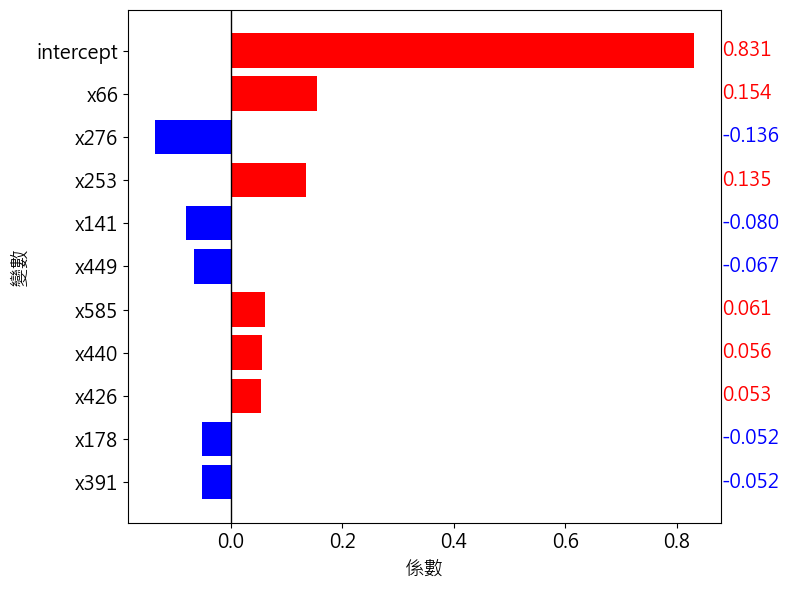

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df_local_final = pd.read_csv(
    "p=02_c0_final_B=50_topk=10_k=2_delta=01_n=100w.csv",
    sep="\t",
    index_col=0
)

feature_col = "feature"   # 特徵名稱欄
coef_col = "coef"         # 係數欄
t_col = "t"               # t 統計量欄

# intercept
df_intercept = df_local_final[
    df_local_final[feature_col].astype(str).str.lower().eq("(intercept)")
]

# 非 intercept，依 |t| 由大到小取前 10 個特徵
df_feature_top10 = (
    df_local_final[
        ~df_local_final[feature_col].astype(str).str.lower().eq("(intercept)")
    ]
    .assign(abs_t=lambda d: d[t_col].abs())
    .sort_values("abs_t", ascending=False)
    .head(10)
)

# 合併：intercept + 10 個特徵，共 11 列
df_plot = pd.concat([df_intercept, df_feature_top10], axis=0)
df_plot[feature_col] = df_plot[feature_col].replace("(intercept)", "intercept")
# y 軸由上而下：intercept, 統計量大到小的特徵
df_plot_for_bar = df_plot.iloc[::-1]
plt.figure(figsize=(8, 6))

# 正係數紅色，負係數藍色
colors = df_plot_for_bar[coef_col].apply(
    lambda x: "red" if x > 0 else "blue"
)

bars = plt.barh(
    df_plot_for_bar[feature_col],
    df_plot_for_bar[coef_col],
    color=colors
)
x_text = df_plot_for_bar[coef_col].max() + 0.05

plt.axvline(0, linewidth=1, color="black")

# 在每個長條右邊標係數值
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    text_color = "red" if width > 0 else "blue"

    plt.text(
        x_text,
        y,
        f"{width:.3f}",
        va="center",
        ha="left",
        fontsize=14,
        color=text_color
    )

plt.xlabel("係數", fontsize=14)
plt.ylabel("變數", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

                         setting        r2      rmse       mae      corr
0  in-domain: g0 on G0 vs f0(G0)  0.707724  0.029946  0.023605  0.841264


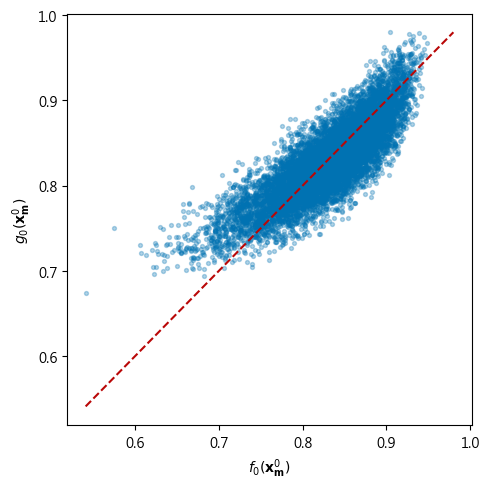

In [21]:
f0_on_G0 = info_big_c0["y_blackbox"]

g0_on_G0 = predict_local_surrogate_from_fullX(
    X_full=info_big_c0["X_local_full"],
    x0_center=info_big_c0["x0_center"],
    block_cols=info_big_c0["block_cols"],
    intercept=info_big_c0["intercept"],
    coef_block=info_big_c0["coef_block"],
)

eval_g0_in = eval_surrogate(f0_on_G0, g0_on_G0)

df_transfer_compare = pd.DataFrame([
    {
        "setting": "in-domain: g0 on G0 vs f0(G0)",
        **eval_g0_in
    }
])

print(df_transfer_compare)

plot_blackbox_vs_local(
    f0_on_G0, g0_on_G0,
    r"$f_0(\mathbf{x}^{0}_{\mathbf{m}})$",
    r"$g_0(\mathbf{x}^{0}_{\mathbf{m}})$",
    seed=42
)


#### target = 1, topk = 1

In [41]:
df_all_runs, df_summary = run_repeat_screening_stats(
    X_all_df=X_all_df,
    c_all=c_all,
    blackbox_by_c=blackbox_by_0,
    p_hat_oof=p_hat_oof,
    thresholds=thresholds,
    B=50,
    topk=1,
    target=1,
    k=2,
    delta=0.1,
    n_block=1_000_000,
    base_seed=42,
)

In [42]:
# df_summary = pd.read_csv(r'C:\Users\No\Documents\GitHub\Thesis\notebooks\p=one_c0_summary_B=50_topk=1_k=2_delta=01_n=100w.csv', sep='\t')
final_cols_c0 = df_summary.query("cluster==0 and select_rate==1.0")["feature_idx"].to_numpy(dtype=int)

c = 0
idx_0 = np.where(c_all == c)[0]
p_hat_0 = np.asarray(p_hat_oof)[idx_0]
loc = pick_x0_indices(p_hat_0, target=1, topk=1)
global_ids = [int(idx_0[pos]) for pos in loc]
x_center_c0 = X_all_df.iloc[global_ids].to_numpy().mean(axis=0)

m0 = next(iter(blackbox_by_0.values()))

info_big_c0 = local_surrogate_fixed_features_bigN(
    x0=x_center_c0,
    blackbox_model=m0,
    block_cols=final_cols_c0,
    delta=0.1,
    k=2,
    scaler=None,
    n_total=2_000_000,
    rng_seed=42,
    center_first=True,
)

feature_names = list(X_all_df.columns)
rows = [{
    "feature": "(intercept)",
    "feature_idx": -1,
    "coef": float(info_big_c0["intercept"]),
    "se": np.nan,
    "t": np.nan,
    "p": float(info_big_c0["intercept_p"]),
    "r2": float(info_big_c0["r2"])
}]
for t, col in enumerate(final_cols_c0):
    rows.append({
        "feature": feature_names[int(col)],
        "feature_idx": int(col),
        "coef": float(info_big_c0["coef_block"][t]),
        "se": float(info_big_c0["se_block"][t]),
        "t": float(info_big_c0["t_block"][t]),
        "p": float(info_big_c0["p_block"][t]),
        "r2": float(info_big_c0["r2"]),
    })

df_local_final = pd.DataFrame(rows).sort_values(["p"], ascending=True).reset_index(drop=True)

In [37]:
df_local_final

,feature,feature_idx,coef,se,t,p,r2
0,(intercept),-1,0.386384,NaN,NaN,0.000000e+00,0.752861
1,x122,112,0.009142,0.000234,39.077215,0.000000e+00,0.752861
2,x274,223,0.008905,0.000234,38.065231,0.000000e+00,0.752861
3,x39,36,-0.142163,0.000234,-607.655875,0.000000e+00,0.752861
4,x7,5,-0.010837,0.000234,-46.298205,0.000000e+00,0.752861
...,...,...,...,...,...,...,...
81,x249,209,-0.003881,0.000234,-16.573652,1.090908e-61,0.752861
82,x41,38,-0.003053,0.000234,-13.041515,7.129180e-39,0.752861
83,x79,71,-0.002731,0.000234,-11.669155,1.836650e-31,0.752861
84,x133,123,-0.002211,0.000234,-9.444857,3.562504e-21,0.752861


In [92]:
print(df_local_final.iloc[0,:])
df_local_final.reindex(df_local_final['t'].abs().sort_values(ascending=False).index).head(11)

feature        (intercept)
feature_idx             -1
coef              0.386384
se                     NaN
t                      NaN
p                      0.0
r2                0.752861
Name: 0, dtype: object


,feature,feature_idx,coef,se,t,p,r2
56,x334,269,0.290322,0.000234,1241.482254,0.0,0.752861
33,x276,225,-0.193906,0.000234,-828.635003,0.0,0.752861
55,x253,213,0.185557,0.000234,792.731807,0.0,0.752861
54,x20,17,0.171103,0.000234,731.221558,0.0,0.752861
3,x39,36,-0.142163,0.000234,-607.655875,0.0,0.752861
53,x446,353,0.117372,0.000234,501.541627,0.0,0.752861
52,x22,19,0.114736,0.000234,490.212292,0.0,0.752861
51,x217,192,0.093159,0.000234,398.174629,0.0,0.752861
30,x103,93,-0.083037,0.000234,-355.061123,0.0,0.752861
29,x141,131,-0.077794,0.000234,-332.489827,0.0,0.752861


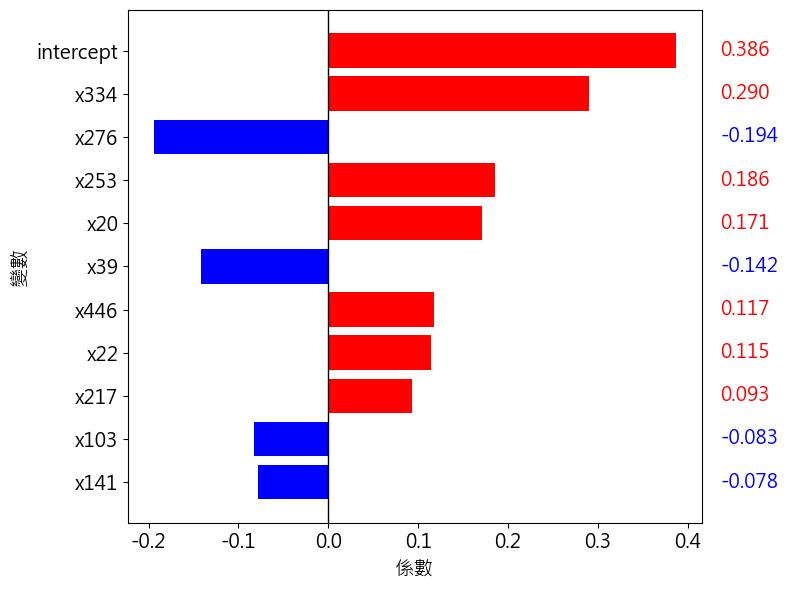

In [5]:
df_local_final = pd.read_csv(
    "p=1_c0_final_B=50_topk=1_k=2_delta=01_n=100w.csv",
    sep="\t",
    index_col=0
)

feature_col = "feature"   # 特徵名稱欄
coef_col = "coef"         # 係數欄
t_col = "t"               # t 統計量欄

# intercept
df_intercept = df_local_final[
    df_local_final[feature_col].astype(str).str.lower().eq("(intercept)")
]

# 非 intercept，依 |t| 由大到小取前 10 個特徵
df_feature_top10 = (
    df_local_final[
        ~df_local_final[feature_col].astype(str).str.lower().eq("(intercept)")
    ]
    .assign(abs_t=lambda d: d[t_col].abs())
    .sort_values("abs_t", ascending=False)
    .head(10)
)

# 合併：intercept + 10 個特徵，共 11 列
df_plot = pd.concat([df_intercept, df_feature_top10], axis=0)
df_plot[feature_col] = df_plot[feature_col].replace("(intercept)", "intercept")
# y 軸由上而下：intercept, 統計量大到小的特徵
df_plot_for_bar = df_plot.iloc[::-1]
plt.figure(figsize=(8, 6))

# 正係數紅色，負係數藍色
colors = df_plot_for_bar[coef_col].apply(
    lambda x: "red" if x > 0 else "blue"
)

bars = plt.barh(
    df_plot_for_bar[feature_col],
    df_plot_for_bar[coef_col],
    color=colors
)
x_text = df_plot_for_bar[coef_col].max() + 0.05

plt.axvline(0, linewidth=1, color="black")

# 在每個長條右邊標係數值
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    text_color = "red" if width > 0 else "blue"

    plt.text(
        x_text,
        y,
        f"{width:.3f}",
        va="center",
        ha="left",
        fontsize=14,
        color=text_color
    )

plt.xlabel("係數", fontsize=14)
plt.ylabel("變數", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

## c = 1

In [66]:
def fit_blackbox_per_cluster(X_all_df, y_all, c_all, random_state=42):
    """
    以分群為單位訓練最終 blackbox（群內先 SMOTE 再 fit），回傳 dict{cluster: model}。
    """
    y_all = np.asarray(y_all)
    
    c=1
    idx = np.where(c_all == c)[0]
    Xc = X_all_df.iloc[idx].values
    yc = y_all[idx]

    sm = SMOTE(sampling_strategy=0.3, k_neighbors=3, random_state=random_state)
    Xc_sm, yc_sm = sm.fit_resample(Xc, yc)

    m = XGBClassifier(
            n_estimators=500,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.6,
            colsample_bytree=0.6,
            min_child_weight=1,
            gamma=0.0,
            reg_lambda=1.0,
            reg_alpha=0.0,
            random_state=42,
            n_jobs=-1,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
        )
    m.fit(Xc_sm, yc_sm)

    return {c: m}

# 2) 最後用全資料重訓每群最終黑箱（用於 lattice 探測與 surrogate 擬合）
blackbox_by_1 = fit_blackbox_per_cluster(X_all_df, y_real, c_all)

def run_block_pvalues_per_cluster_center_Nrounds_fullp(
    X_all_df, c_all, blackbox_by_c, p_hat_oof, thresholds,
    topk, target, k, n_block,
    delta=0.1, base_seed=42,
):
    """
    對每個 cluster：挑選 x0（靠近 target 機率），取中心點 x_center，
    再呼叫 run_3round_fullp_screening 得到 df 與每群的最終特徵集合。
    """
    out = []
    cfinal_col = {}
    feature_names = list(X_all_df.columns)

    c=1
    idx_c = np.where(c_all == c)[0]
    m = blackbox_by_c[c]
    p_hat_c = np.asarray(p_hat_oof)[idx_c]

    loc = pick_x0_indices(p_hat_c, target=target, topk=topk)
    if len(loc) == 0:
        cfinal_col[c] = np.array([], dtype=int)
        return pd.DataFrame(), cfinal_col

    global_ids = [int(idx_c[pos]) for pos in loc]
    x_center = X_all_df.iloc[global_ids].to_numpy().mean(axis=0)

    df_rounds, final_cols = run_Nround_fullp_screening(
        x0=x_center,
        blackbox_model=m,
        feature_names=feature_names,
        k=k,
        delta=delta,
        scaler=None,
        n_block=n_block,
        base_seed=base_seed + 1000 * c,
        thresholds=thresholds,
    )

    cfinal_col[c] = np.asarray(final_cols, dtype=int)

    if len(df_rounds):
        df_rounds["cluster"] = c
        df_rounds["x0_indices"] = [global_ids] * len(df_rounds)
        df_rounds["p_oof_center"] = float(p_hat_c[loc].mean())
        df_rounds["p_final_center"] = float(m.predict_proba(x_center.reshape(1, -1))[:, 1][0])
        out.append(df_rounds)

    df_all = pd.concat(out, ignore_index=True) if len(out) else pd.DataFrame()
    return df_all, cfinal_col


def run_repeat_screening_stats(
    X_all_df, c_all, blackbox_by_c, p_hat_oof,
    thresholds, topk, target, n_block,
    k=2, 
    B=50,
    delta=0.1,
    base_seed=42,
):
    """
    重複跑 B 次 N-round 篩選（每次用不同 seed），回傳：
      1) df_all_runs：所有 run 的 df_rounds 串起來（可選）
      2) df_summary：每群每特徵的選中次數與 beta(mean±SE)
    """
    feature_names = list(X_all_df.columns)
    p = len(feature_names)
    c=1
    # 收集：每個 cluster、每個 feature 的「被選到 p* 次數」與「最終輪 beta 列表」
    select_count = {c: np.zeros(p, dtype=np.int32)}
    beta_list = {c: {i: [] for i in range(p)}}

    df_all_runs = []

    for b in range(B):
        # 每次重複都換一組 seed（確保每輪抽到不同 D、跨 run 也不同）
        run_seed = int(base_seed + 1_000_000 * b)

        df_all_p, cfinal_col = run_block_pvalues_per_cluster_center_Nrounds_fullp(
            X_all_df=X_all_df,
            c_all=c_all,
            blackbox_by_c=blackbox_by_c,
            p_hat_oof=p_hat_oof,
            thresholds=thresholds,
            topk=topk,
            target=target,
            k=k,
            delta=delta,
            n_block=n_block,
            base_seed=run_seed,
        )

        if len(df_all_p):
            df_all_p = df_all_p.copy()
            df_all_p["run_id"] = b
            df_all_runs.append(df_all_p)

        # 逐 cluster：統計 p* 次數與最終輪 beta
        final_cols = np.asarray(cfinal_col.get(c, []), dtype=int)
        if final_cols.size == 0:
            continue

        select_count[c][final_cols] += 1

        # 從 df_all_p 取該 cluster 的「最後一輪」結果，抓出 p* 的 coef
        df_c = df_all_p[df_all_p["cluster"] == c]
        if len(df_c) == 0:
            continue

        last_round = int(df_c["round_id"].max())
        df_last = df_c[df_c["round_id"] == last_round]

        df_last_star = df_last[df_last["feature_idx"].isin(final_cols)][["feature_idx", "coef"]]
        for _, row in df_last_star.iterrows():
            beta_list[c][int(row["feature_idx"])].append(float(row["coef"]))

    # 彙總成表
    rows = []
    cnt = select_count[c]
    for j in np.where(cnt > 0)[0]:
        betas = np.asarray(beta_list[c][int(j)], dtype=float)
        if betas.size == 0:
            continue
        mean = float(betas.mean())
        se = float(betas.std(ddof=1) / np.sqrt(betas.size)) if betas.size >= 2 else np.nan

        rows.append({
            "cluster": c,
            "feature": feature_names[int(j)],
            "feature_idx": int(j),
            "select_count": int(cnt[int(j)]),
            "select_rate": float(cnt[int(j)] / B),
            "beta_n": int(betas.size),
            "beta_mean": mean,
            "beta_se": se,
            "beta_mean_minus_se": float(mean - se) if np.isfinite(se) else np.nan,
            "beta_mean_plus_se": float(mean + se) if np.isfinite(se) else np.nan,
        })

    df_summary = pd.DataFrame(rows)
    if len(df_summary):
        df_summary = df_summary.sort_values(
            ["cluster", "select_count", "beta_mean"],
            ascending=[True, False, False]
        ).reset_index(drop=True)

    df_all_runs = pd.concat(df_all_runs, ignore_index=True) if len(df_all_runs) else pd.DataFrame()
    return df_all_runs, df_summary

thresholds = (0.01, 0.005, 0.001, 0.0005, 0.0001)

### target = 0.2, topk = 4

In [67]:
df1_all_runs, df1_summary = run_repeat_screening_stats(
    X_all_df=X_all_df,
    c_all=c_all,
    blackbox_by_c=blackbox_by_1,
    p_hat_oof=p_hat_oof,
    thresholds=thresholds,
    B=50,
    topk=4,
    target=0.2,
    k=2,
    delta=0.1,
    n_block=1_000_000,
    base_seed=42,
)

In [68]:
# df1_summary = pd.read_csv(r'C:\Users\No\Documents\GitHub\Thesis\notebooks\p=half_c1_summary_B=50_topk=7_k=2_delta=01_n=100w.csv', sep='\t')
final_cols_c1 = df1_summary.query("cluster==1 and select_rate==1.0")["feature_idx"].to_numpy(dtype=int)

c = 1
idx_1 = np.where(c_all == c)[0]
p_hat_1 = np.asarray(p_hat_oof)[idx_1]
loc = pick_x0_indices(p_hat_1, target=0.2, topk=4)
global_ids = [int(idx_1[pos]) for pos in loc]
x_center_c1 = X_all_df.iloc[global_ids].to_numpy().mean(axis=0)

m1 = next(iter(blackbox_by_1.values()))

info_big_c1 = local_surrogate_fixed_features_bigN(
    x0=x_center_c1,
    blackbox_model=m1,
    block_cols=final_cols_c1,
    delta=0.1,
    k=2,
    scaler=None,           
    n_total=2_000_000,
    rng_seed=42,
    center_first=True,
)

feature_names = list(X_all_df.columns)
rows = [{
    "feature": "(intercept)",
    "feature_idx": -1,
    "coef": float(info_big_c1["intercept"]),
    "se": np.nan,
    "t": np.nan,
    "p": float(info_big_c1["intercept_p"]),
    "r2": float(info_big_c1["r2"])
}]
for t, col in enumerate(final_cols_c1):
    rows.append({
        "feature": feature_names[int(col)],
        "feature_idx": int(col),
        "coef": float(info_big_c1["coef_block"][t]),
        "se": float(info_big_c1["se_block"][t]),
        "t": float(info_big_c1["t_block"][t]),
        "p": float(info_big_c1["p_block"][t]),
        "r2": float(info_big_c1["r2"]),
    })

df1_local_final = pd.DataFrame(rows).sort_values(["p"], ascending=True).reset_index(drop=True)

In [95]:
print(df1_local_final.iloc[0,:])
df1_local_final.reindex(df1_local_final['t'].abs().sort_values(ascending=False).index).head(10)

feature        (intercept)
feature_idx             -1
coef              0.532759
se                     NaN
t                      NaN
p                      0.0
r2                0.655882
Name: 0, dtype: object


,feature,feature_idx,coef,se,t,p,r2
66,x34,31,0.435534,0.00043,1012.782642,0.0,0.655882
37,x578,446,-0.295499,0.00043,-687.242894,0.0,0.655882
51,x76,68,0.274886,0.00043,639.369900,0.0,0.655882
39,x349,282,0.234447,0.00043,545.118796,0.0,0.655882
40,x303,248,0.161240,0.00043,374.975038,0.0,0.655882
41,x184,168,0.159131,0.00043,370.147867,0.0,0.655882
9,x287,234,-0.151920,0.00043,-353.200014,0.0,0.655882
43,x517,397,0.129322,0.00043,300.803530,0.0,0.655882
44,x164,150,0.126463,0.00043,294.130336,0.0,0.655882
20,x384,304,-0.117880,0.00043,-274.158262,0.0,0.655882


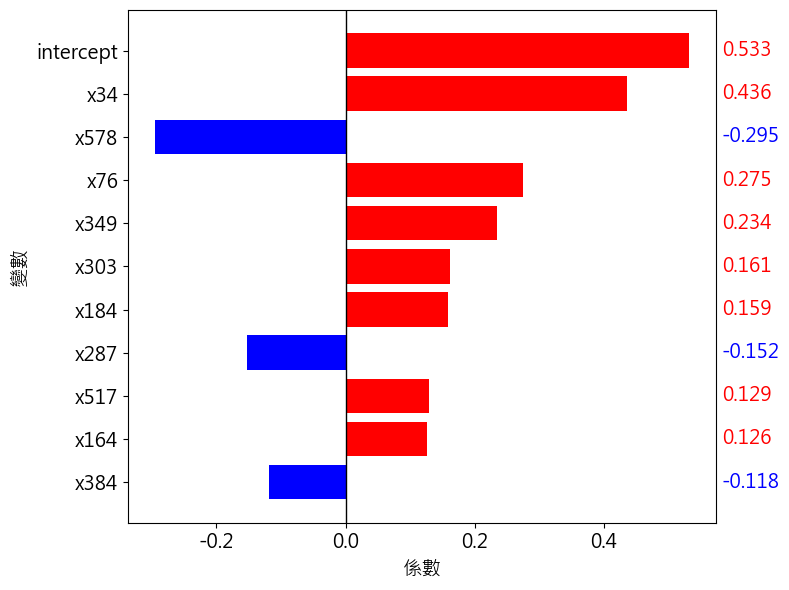

In [6]:
df_local_final = pd.read_csv(
    "p=02_c1_final_B=50_topk=4_k=2_delta=01_n=100w.csv",
    sep="\t",
    index_col=0
)

feature_col = "feature"   # 特徵名稱欄
coef_col = "coef"         # 係數欄
t_col = "t"               # t 統計量欄

# intercept
df_intercept = df_local_final[
    df_local_final[feature_col].astype(str).str.lower().eq("(intercept)")
]

# 非 intercept，依 |t| 由大到小取前 10 個特徵
df_feature_top10 = (
    df_local_final[
        ~df_local_final[feature_col].astype(str).str.lower().eq("(intercept)")
    ]
    .assign(abs_t=lambda d: d[t_col].abs())
    .sort_values("abs_t", ascending=False)
    .head(10)
)

# 合併：intercept + 10 個特徵，共 11 列
df_plot = pd.concat([df_intercept, df_feature_top10], axis=0)
df_plot[feature_col] = df_plot[feature_col].replace("(intercept)", "intercept")
# y 軸由上而下：intercept, 統計量大到小的特徵
df_plot_for_bar = df_plot.iloc[::-1]

plt.figure(figsize=(8, 6))

# 正係數紅色，負係數藍色
colors = df_plot_for_bar[coef_col].apply(
    lambda x: "red" if x > 0 else "blue"
)

bars = plt.barh(
    df_plot_for_bar[feature_col],
    df_plot_for_bar[coef_col],
    color=colors
)
x_text = df_plot_for_bar[coef_col].max() + 0.05

plt.axvline(0, linewidth=1, color="black")

# 在每個長條右邊標係數值
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    text_color = "red" if width > 0 else "blue"

    plt.text(
        x_text,
        y,
        f"{width:.3f}",
        va="center",
        ha="left",
        fontsize=14,
        color=text_color
    )

plt.xlabel("係數", fontsize=14)
plt.ylabel("變數", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

                         setting        r2      rmse       mae      corr
0  in-domain: g1 on G1 vs f1(G1)  0.732848  0.038968  0.030348  0.856065


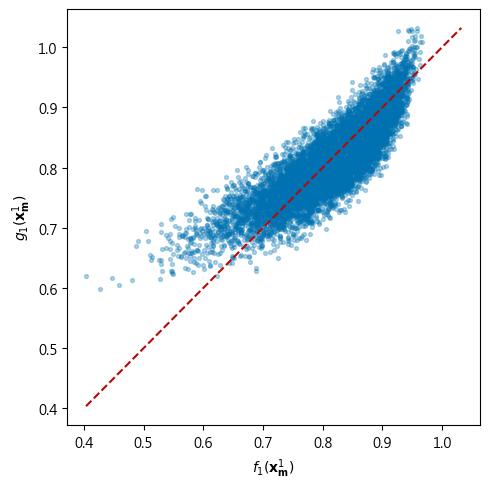

In [23]:
f1_on_G1 = info_big_c1["y_blackbox"]

g1_on_G1 = predict_local_surrogate_from_fullX(
    X_full=info_big_c1["X_local_full"],
    x0_center=info_big_c1["x0_center"],
    block_cols=info_big_c1["block_cols"],
    intercept=info_big_c1["intercept"],
    coef_block=info_big_c1["coef_block"],
)

eval_g1_in = eval_surrogate(f1_on_G1, g1_on_G1)

df_transfer_compare = pd.DataFrame([
    {
        "setting": "in-domain: g1 on G1 vs f1(G1)",
        **eval_g1_in
    }
])

print(df_transfer_compare)

plot_blackbox_vs_local(
    f1_on_G1, g1_on_G1,
    r"$f_1(\mathbf{x}^{1}_{\mathbf{m}})$",
    r"$g_1(\mathbf{x}^{1}_{\mathbf{m}})$",
    seed=42
)

---
---

### target = 0.6, topk = 2

In [99]:
df1_all_runs, df1_summary = run_repeat_screening_stats(
    X_all_df=X_all_df,
    c_all=c_all,
    blackbox_by_c=blackbox_by_1,
    p_hat_oof=p_hat_oof,
    thresholds=thresholds,
    B=50,
    topk=2,
    target=0.6,
    k=2,
    delta=0.1,
    n_block=1_000_000,
    base_seed=42,
)

In [100]:
# df1_summary = pd.read_csv(r'C:\Users\No\Documents\GitHub\Thesis\notebooks\p=one_c1_summary_B=50_topk=2_k=2_delta=01_n=100w.csv', sep='\t')
final_cols_c1 = df1_summary.query("cluster==1 and select_rate==1.0")["feature_idx"].to_numpy(dtype=int)

c = 1
idx_1 = np.where(c_all == c)[0]
p_hat_1 = np.asarray(p_hat_oof)[idx_1]
loc = pick_x0_indices(p_hat_1, target=0.6, topk=2)
global_ids = [int(idx_1[pos]) for pos in loc]
x_center_c1 = X_all_df.iloc[global_ids].to_numpy().mean(axis=0)

m1 = next(iter(blackbox_by_1.values()))

info_big_c1 = local_surrogate_fixed_features_bigN(
    x0=x_center_c1,
    blackbox_model=m1,
    block_cols=final_cols_c1,
    delta=0.1,
    k=2,
    scaler=None,
    n_total=2_000_000,
    rng_seed=42,
    center_first=True,
)

feature_names = list(X_all_df.columns)
rows = [{
    "feature": "(intercept)",
    "feature_idx": -1,
    "coef": float(info_big_c1["intercept"]),
    "se": np.nan,
    "t": np.nan,
    "p": float(info_big_c1["intercept_p"]),
    "r2": float(info_big_c1["r2"])
}]
for t, col in enumerate(final_cols_c1):
    rows.append({
        "feature": feature_names[int(col)],
        "feature_idx": int(col),
        "coef": float(info_big_c1["coef_block"][t]),
        "se": float(info_big_c1["se_block"][t]),
        "t": float(info_big_c1["t_block"][t]),
        "p": float(info_big_c1["p_block"][t]),
        "r2": float(info_big_c1["r2"]),
    })

df1_local_final = pd.DataFrame(rows).sort_values(["p"], ascending=True).reset_index(drop=True)

In [102]:
print(df1_local_final.iloc[0,:])
df1_local_final.reindex(df1_local_final['t'].abs().sort_values(ascending=False).index).head(10)

feature        (intercept)
feature_idx             -1
coef              0.972111
se                     NaN
t                      NaN
p                      0.0
r2                 0.63995
Name: 0, dtype: object


,feature,feature_idx,coef,se,t,p,r2
68,x386,306,0.041250,0.000048,867.180920,0.0,0.63995
36,x420,328,-0.029829,0.000048,-626.932793,0.0,0.63995
70,x501,394,0.028608,0.000048,601.651100,0.0,0.63995
13,x117,107,-0.025810,0.000048,-542.744910,0.0,0.63995
71,x16,13,0.024973,0.000048,525.176100,0.0,0.63995
65,x578,446,0.023905,0.000048,502.437671,0.0,0.63995
19,x28,25,-0.018258,0.000048,-384.093415,0.0,0.63995
20,x384,304,-0.016011,0.000048,-336.989477,0.0,0.63995
21,x287,234,-0.014609,0.000048,-307.184404,0.0,0.63995
63,x517,397,0.013159,0.000048,276.637814,0.0,0.63995


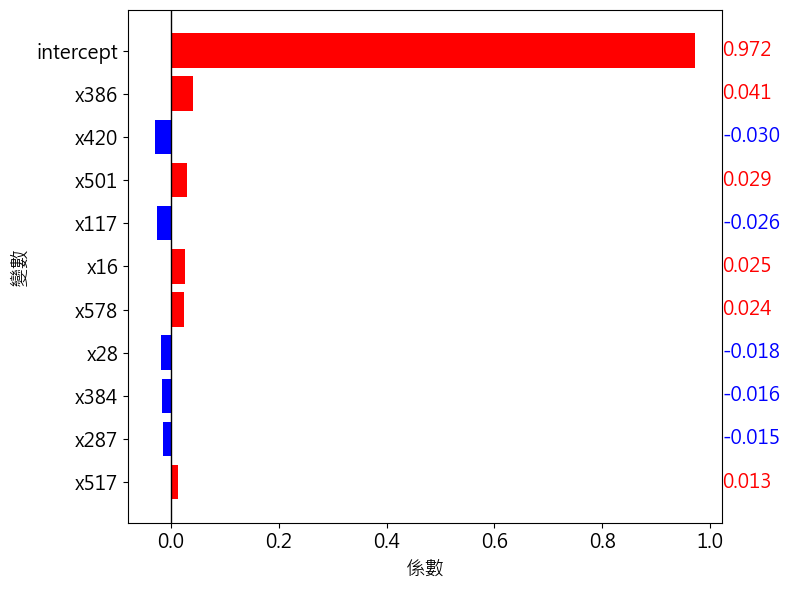

In [7]:
df_local_final = pd.read_csv(
    "p=06_c1_final_B=50_topk=2_k=2_delta=01_n=100w.csv",
    sep="\t",
    index_col=0
)

feature_col = "feature"   # 特徵名稱欄
coef_col = "coef"         # 係數欄
t_col = "t"               # t 統計量欄

# intercept
df_intercept = df_local_final[
    df_local_final[feature_col].astype(str).str.lower().eq("(intercept)")
]

# 非 intercept，依 |t| 由大到小取前 10 個特徵
df_feature_top10 = (
    df_local_final[
        ~df_local_final[feature_col].astype(str).str.lower().eq("(intercept)")
    ]
    .assign(abs_t=lambda d: d[t_col].abs())
    .sort_values("abs_t", ascending=False)
    .head(10)
)

# 合併：intercept + 10 個特徵，共 11 列
df_plot = pd.concat([df_intercept, df_feature_top10], axis=0)
df_plot[feature_col] = df_plot[feature_col].replace("(intercept)", "intercept")
# y 軸由上而下：intercept, 統計量大到小的特徵
df_plot_for_bar = df_plot.iloc[::-1]
plt.figure(figsize=(8, 6))

# 正係數紅色，負係數藍色
colors = df_plot_for_bar[coef_col].apply(
    lambda x: "red" if x > 0 else "blue"
)

bars = plt.barh(
    df_plot_for_bar[feature_col],
    df_plot_for_bar[coef_col],
    color=colors
)
x_text = df_plot_for_bar[coef_col].max() + 0.05

plt.axvline(0, linewidth=1, color="black")

# 在每個長條右邊標係數值
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    text_color = "red" if width > 0 else "blue"

    plt.text(
        x_text,
        y,
        f"{width:.3f}",
        va="center",
        ha="left",
        fontsize=14,
        color=text_color
    )

plt.xlabel("係數", fontsize=14)
plt.ylabel("變數", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()